## 1 этап. Изучение датасета GQA-ru

Загрузим данные
Датасет состоит из 2 частей: инструкции и изображения, для изучения на 1 этапе будет досаточно только инструкций

In [1]:
from datasets import load_dataset

instructions = load_dataset("deepvk/GQA-ru", "train_balanced_instructions", split="train[:1000]")

In [4]:
instructions[0]

{'id': '02633845',
 'imageId': '2395730',
 'question': 'Кто в рубашке?',
 'answer': 'парень',
 'fullAnswer': 'Парень в рубашке',
 'isBalanced': True,
 'groups': {'global': 'person', 'local': '14-shirt_wearing,s'},
 'entailed': '[]',
 'equivalent': "['02633845']",
 'types': {'structural': 'query', 'semantic': 'rel', 'detailed': 'relS'},
 'annotations': {'question': [{'objectId': '4', 'value': '1203432'}],
  'answer': [{'objectId': '0', 'value': '3822894'}],
  'fullAnswer': [{'objectId': '1', 'value': '3822894'},
   {'objectId': '5', 'value': '1203432'}]},
 'semantic': [{'operation': 'select',
   'argument': 'shirt (1203432)',
   'dependencies': []},
  {'operation': 'relate',
   'argument': 'person,wearing,s (3822894)',
   'dependencies': [0]},
  {'operation': 'query', 'argument': 'name', 'dependencies': [1]}],
 'semanticStr': 'select: shirt (1203432)->relate: person,wearing,s (3822894) [0]->query: name [1]'}

In [5]:
instructions.column_names

['id',
 'imageId',
 'question',
 'answer',
 'fullAnswer',
 'isBalanced',
 'groups',
 'entailed',
 'equivalent',
 'types',
 'annotations',
 'semantic',
 'semanticStr']

In [8]:
for i in range(5):
    j = instructions[i]
    print("imageId", j["imageId"])
    print("question", j["question"])
    print("answer", j["answer"])
    print("fullAnswer", j["fullAnswer"])
    print()

imageId 2395730
question Кто в рубашке?
answer парень
fullAnswer Парень в рубашке

imageId 2324428
question Какое это место?
answer город
fullAnswer Это город

imageId 2384606
question На чем горчица?
answer на сосиске
fullAnswer Горчица на сосиске

imageId 2373802
question На чём находится логотип?
answer на машине
fullAnswer Логотип находится на машине

imageId 2355124
question Какое устройство слева от женщины?
answer камера
fullAnswer Устройство — камера



In [9]:
import pandas as pd
df = pd.DataFrame(instructions)
df.head()

,id,imageId,question,answer,fullAnswer,isBalanced,groups,entailed,equivalent,types,annotations,semantic,semanticStr
0,02633845,2395730,Кто в рубашке?,парень,Парень в рубашке,True,"{'global': 'person', 'local': '14-shirt_wearin...",[],['02633845'],"{'structural': 'query', 'semantic': 'rel', 'de...","{'question': [{'objectId': '4', 'value': '1203...","[{'operation': 'select', 'argument': 'shirt (1...","select: shirt (1203432)->relate: person,wearin..."
1,18753702,2324428,Какое это место?,город,Это город,True,"{'global': 'place', 'local': '02q-place'}","['18753701', '18753703', '18753704', '18753705...",['18753702'],"{'structural': 'query', 'semantic': 'global', ...","{'question': [], 'answer': [], 'fullAnswer': []}","[{'operation': 'select', 'argument': 'scene', ...",select: scene->query: place [0]
2,1078215,2384606,На чем горчица?,на сосиске,Горчица на сосиске,True,"{'global': 'meat', 'local': '14-mustard_on,o'}","['1078217', '1078216', '1078218']",['1078215'],"{'structural': 'query', 'semantic': 'rel', 'de...","{'question': [], 'answer': [{'objectId': '0', ...","[{'operation': 'select', 'argument': 'mustard ...","select: mustard (525621)->relate: _,on,o (5256..."
3,14231369,2373802,На чём находится логотип?,на машине,Логотип находится на машине,True,"{'global': '', 'local': '14-logo_on,o'}",[],['14231369'],"{'structural': 'query', 'semantic': 'rel', 'de...","{'question': [], 'answer': [{'objectId': '0', ...","[{'operation': 'select', 'argument': 'logo (26...","select: logo (2625822)->relate: _,on,o (372444..."
4,07113179,2355124,Какое устройство слева от женщины?,камера,Устройство — камера,True,"{'global': 'device', 'local': '15-woman_to the...","['07113180', '07113181', '07113182', '07113183...",['07113179'],"{'structural': 'query', 'semantic': 'rel', 'de...","{'question': [{'objectId': '3', 'value': '8325...","[{'operation': 'select', 'argument': 'woman (8...","select: woman (832602)->relate: device,to the ..."


In [14]:
df_small = df[["imageId", "question", "answer", "fullAnswer"]]
df_small.head(20)

,imageId,question,answer,fullAnswer
0,2395730,Кто в рубашке?,парень,Парень в рубашке
1,2324428,Какое это место?,город,Это город
2,2384606,На чем горчица?,на сосиске,Горчица на сосиске
3,2373802,На чём находится логотип?,на машине,Логотип находится на машине
4,2355124,Какое устройство слева от женщины?,камера,Устройство — камера
5,2346503,Что находится на столбе?,знак улицы,На столбе находится знак улицы
6,2328709,Что изображено на фото?,тротуар,На нем изображен тротуар
7,713861,Девочка справа от миски?,нет,"Нет, девочка слева от миски"
8,2395913,Чем покрыт этот стол?,бумагой,Стол покрыт бумагой
9,2369599,На чем лежит бумага?,на сиденье,Бумага лежит на сиденье


In [11]:
df_small["answer"].value_counts().head(20)

answer
нет          188
да           179
слева         54
справа        52
стол          12
стул          11
мужчина       11
собака         7
женщина        7
парень         6
лошадь         6
кровать        6
цвет           5
внизу          5
полка          5
маленькая      5
хот-дог        5
в верхней      5
красного       5
в нижней       5
Name: count, dtype: int64

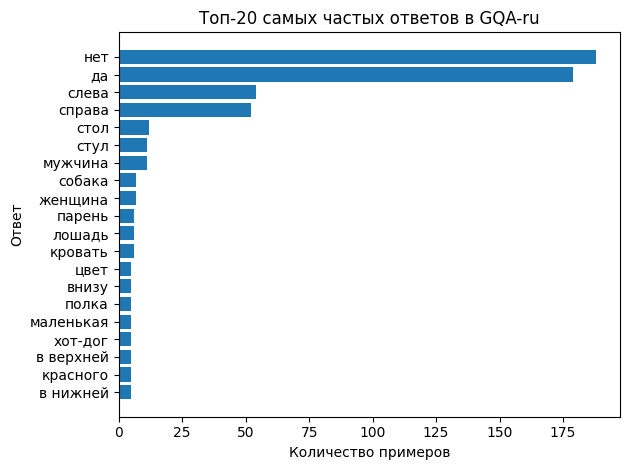

In [23]:
import matplotlib.pyplot as plt

top_answers = df_small["answer"].value_counts().head(20)


plt.barh(top_answers.index[::-1], top_answers.values[::-1])

plt.title("Топ-20 самых частых ответов в GQA-ru")
plt.xlabel("Количество примеров")
plt.ylabel("Ответ")

plt.tight_layout()
plt.show()

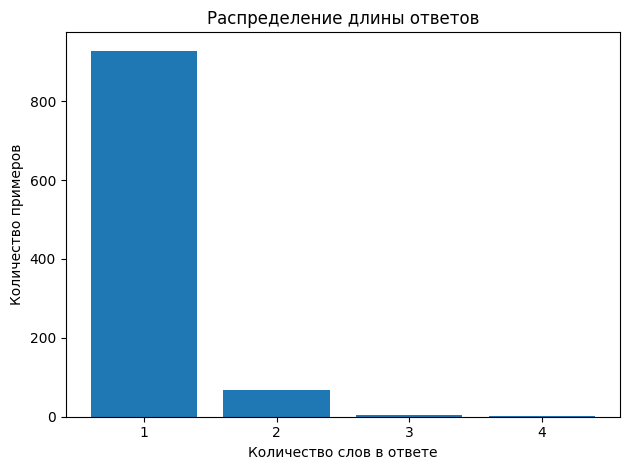

In [22]:
import matplotlib.pyplot as plt

df_small["answer_len"] = df_small["answer"].astype(str).apply(lambda x: len(x.split()))
len_answers = df_small["answer_len"].value_counts().sort_index()

plt.bar(len_answers.index, len_answers.values)

plt.title("Распределение длины ответов")
plt.xlabel("Количество слов в ответе")
plt.ylabel("Количество примеров")

plt.xticks(len_answers.index)
plt.tight_layout()
plt.show()


In [24]:
df_small["question"].value_counts().head(20)

question
Какое это место?                      4
Что это за место?                     4
Это сцена на улице?                   3
Что на стене?                         3
Кто в рубашке?                        2
Что делает мужчина?                   2
Кто носит рубашку?                    2
Как называется это животное?          2
Какого цвета земля?                   2
Это внутри или снаружи?               2
Кто носит обувь?                      2
Какого цвета брюки?                   2
Что держит женщина?                   2
Где была сделана фотография?          2
С какой стороны находится женщина?    2
Что она держит?                       2
Кто стоит?                            2
Что это за мебель?                    2
Из чего сделан стул?                  2
Эти животные разных видов?            2
Name: count, dtype: int64